# Chatbot with Persistance

# Persistence, Checkpoint & Thread

### 🔹 Persistence

**Persistence** means saving the state or conversation so that previous information can be used in later interactions.

### 🔹 Checkpoint

A **checkpoint** is a saved version of the graph's state at a particular point during execution.

### 🔹 Thread

A **thread** is a unique ID used to identify and maintain a particular conversation.

### 📌 In Simple Words

| Term            | Meaning                                    |
| --------------- | ------------------------------------------ |
| **Persistence** | Saving information for future use          |
| **Checkpoint**  | A saved snapshot of the graph's state      |
| **Thread**      | A unique ID that identifies a conversation |


# Benefits of Persistence

### 🔹 Short-Term Memory

Stores information during a conversation so the system can **remember previous interactions**.

### 🔹 Fault Tolerance

If an error or interruption occurs, the workflow can **recover from a saved checkpoint** instead of starting again.

### 🔹 Human-in-the-Loop (HITL)

Allows a **human to review, approve, or modify** the workflow at a particular point before continuing.

### 🔹 Time Travel

Allows you to **go back to a previous checkpoint/state** and continue execution from that point.

### 📌 In Simple Words

| Feature               | Meaning                                    |
| --------------------- | ------------------------------------------ |
| **Short-Term Memory** | Remember information during a conversation |
| **Fault Tolerance**   | Recover after failure or interruption      |
| **HITL**              | Human can review or control the workflow   |
| **Time Travel**       | Go back to a previous saved state          |


In [1]:
#Define Library
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
#Saving data in memory
from langgraph.checkpoint.memory import MemorySaver

In [2]:
#local ollama
from langchain_ollama import ChatOllama
model = ChatOllama(model="gemma3:4b")
response = model.invoke("the capital of India? in one word")
print(response.content)

Delhi


In [3]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [4]:
def chat_node(state : ChatState):
    #take a query from state
    message=state['messages']

    #Send to LLM
    response=model.invoke(message)

    #response store state
    return{'messages':[response]}
    

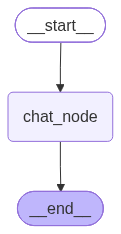

In [5]:
graph=StateGraph(ChatState)

#node
graph.add_node('chat_node',chat_node)

#edge
graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

#create checkpoint for data saving
checkpointer = MemorySaver()
workflow=graph.compile(checkpointer=checkpointer)
workflow

In [ ]:
#define thread
thread_id='1'
while True:
    user_message=input('Type here : ')
    print('User :',user_message)
    if user_message.strip().lower() in ['exit','quit','bye']:
       break   

    config= {'configurable' :{'thread_id':thread_id}}
    #response=workflow.invoke({'messages':[HumanMessage(content=user_message)]})
    response=workflow.invoke({'messages':[HumanMessage(content=user_message)]},config=config)
    print('AI :' ,response['messages'][-1].content)

Type here :  capital of india


User : capital of india
AI : The capital of India is **New Delhi**. 

It was officially designated as the capital in 1911, replacing Calcutta (now Kolkata).



Type here :  add 10+5


User : add 10+5
AI : 10 + 5 = 15 




Type here :  add 5 in result


User : add 5 in result
AI : 15 + 5 = 20 




**----------------------------------------------------------------------------------------**

# 🤖 Chatbot with Persistence

The main purpose of this notebook is to create a **chatbot that can remember previous messages**.

For example:

```text
User: Add 10 + 5
AI: 15

User: Add 5 in result
AI: 20
```

The chatbot can understand **"result"** because the previous conversation is stored.

---

# 1. Import Required Libraries

```python
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.checkpoint.memory import MemorySaver
```

### What do these libraries do?

| Library        | Purpose                            |
| -------------- | ---------------------------------- |
| `StateGraph`   | Creates the LangGraph workflow     |
| `START`        | Starting point of the workflow     |
| `END`          | Ending point of the workflow       |
| `TypedDict`    | Defines the structure of the state |
| `BaseMessage`  | Base type for messages             |
| `HumanMessage` | Represents the user's message      |
| `MemorySaver`  | Saves the graph state/checkpoints  |

---

# 2. Connect Ollama Model

The notebook uses a local Ollama model:

```python
from langchain_ollama import ChatOllama

model = ChatOllama(model="gemma3:4b")
```

Here:

```text
gemma3:4b
```

is the local LLM model.

We can test the model:

```python
response = model.invoke("the capital of India? in one word")

print(response.content)
```

Output:

```text
Delhi
```

### Simple Flow

```text
Question
   ↓
Ollama
   ↓
gemma3:4b
   ↓
Answer
```

---

# 3. Create ChatState

The notebook defines:

```python
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
```

## What is `ChatState`?

`ChatState` is the **state/memory structure of our chatbot**.

It contains:

```text
messages
```

For example:

```text
messages = [
    HumanMessage("Add 10 + 5"),
    AIMessage("15")
]
```

After another question:

```text
messages = [
    HumanMessage("Add 10 + 5"),
    AIMessage("15"),
    HumanMessage("Add 5 in result"),
    AIMessage("20")
]
```

So the `messages` list contains the conversation.

---

# 4. What is `add_messages`?

We have:

```python
messages: Annotated[list[BaseMessage], add_messages]
```

The important part is:

```python
add_messages
```

It tells LangGraph to **add new messages to the existing messages**.

Conceptually:

```text
Old Messages
     +
New Message
     ↓
Updated Messages
```

Therefore, the conversation history can be maintained in the state.

---

# 5. Create the Chat Node

The notebook defines:

```python
def chat_node(state: ChatState):

    # take messages from state
    message = state['messages']

    # send messages to LLM
    response = model.invoke(message)

    # store response in state
    return {'messages': [response]}
```

Let's understand this step-by-step.

---

## 5.1 Receive the State

```python
def chat_node(state: ChatState):
```

The `chat_node` receives the current state.

The state contains:

```text
ChatState
   ↓
messages
```

---

## 5.2 Get Messages from State

```python
message = state['messages']
```

This gets the conversation messages from the state.

For example:

```text
User: Add 10 + 5
AI: 15
User: Add 5 in result
```

---

## 5.3 Send Messages to the LLM

```python
response = model.invoke(message)
```

The messages are sent to the Ollama model.

```text
Messages
   ↓
Ollama
   ↓
gemma3:4b
   ↓
AI Response
```

---

## 5.4 Store the AI Response

```python
return {'messages': [response]}
```

The AI response is returned to the state.

So:

```text
User Message
     ↓
ChatState
     ↓
chat_node
     ↓
LLM
     ↓
AI Response
     ↓
ChatState
```

---

# 6. Create the LangGraph

Now we create the graph:

```python
graph = StateGraph(ChatState)
```

This means:

> Create a LangGraph workflow using `ChatState`.

Conceptually:

```text
ChatState
    ↓
LangGraph
```

---

# 7. Add the Chat Node

```python
graph.add_node('chat_node', chat_node)
```

Here:

```text
'chat_node'
```

is the **name of the node**.

And:

```text
chat_node
```

is the Python function that will execute.

So:

```text
Node Name          Function

chat_node    →     chat_node()
```

---

# 8. Connect START to Chat Node

```python
graph.add_edge(START, 'chat_node')
```

This means:

```text
START
  ↓
chat_node
```

When the workflow starts, it goes to `chat_node`.

---

# 9. Connect Chat Node to END

```python
graph.add_edge('chat_node', END)
```

This means:

```text
START
  ↓
chat_node
  ↓
END
```

So this is a simple workflow with only one processing node.

---

# 10. Create a Checkpoint

Now we create the checkpointer:

```python
checkpointer = MemorySaver()
```

## What is a Checkpoint?

A checkpoint is a **saved version of the graph's state**.

Think of it like saving your work:

```text
Conversation
     ↓
Save
     ↓
Checkpoint
```

`MemorySaver()` saves the state in memory during the running program.

---

# 11. Compile the Workflow

The notebook uses:

```python
workflow = graph.compile(checkpointer=checkpointer)
```

This converts the graph into an executable workflow.

At the same time, we tell LangGraph:

> Use `MemorySaver` to save checkpoints.

So:

```text
StateGraph
    +
MemorySaver
    ↓
Compiled Workflow
```

---

# 12. What is Persistence?

**Persistence** means maintaining the state/conversation so that previous information can be used in later interactions.

In this notebook:

```text
Conversation
     ↓
ChatState
     ↓
Checkpoint
     ↓
Thread ID
     ↓
Previous state can be accessed
```

This allows the chatbot to behave like a continuing conversation rather than treating every question as completely independent.

---

# 13. What is a Thread?

The notebook defines:

```python
thread_id = '1'
```

A **thread** identifies a particular conversation.

Think of it as a **conversation ID**.

For example:

```text
Thread 1
──────────────
User: Add 10 + 5
AI: 15

User: Add 5 in result
AI: 20
```

Another conversation could use:

```python
thread_id = '2'
```

Conceptually:

```text
Thread 1 → Conversation 1

Thread 2 → Conversation 2
```

---

# 14. Create the Thread Configuration

The notebook creates:

```python
config = {
    'configurable': {
        'thread_id': thread_id
    }
}
```

This tells LangGraph:

> Use this `thread_id` for this conversation.

For this notebook:

```text
thread_id = "1"
```

So LangGraph associates the conversation with **Thread 1**.

---

# 15. Start the Chatbot Loop

The notebook uses:

```python
while True:
```

This creates a continuous chatbot.

Conceptually:

```text
Ask Question
     ↓
Get Answer
     ↓
Ask Question
     ↓
Get Answer
     ↓
Ask Question
     ↓
...
```

The loop continues until the user enters an exit command.

---

# 16. Take User Input

The notebook uses:

```python
user_message = input('Type here : ')
```

The user enters a message.

For example:

```text
Type here : add 10+5
```

Then:

```python
print('User :', user_message)
```

Output:

```text
User : add 10+5
```

---

# 17. Exit Condition

The notebook contains:

```python
if user_message.strip().lower() in ['exit', 'quit', 'bye']:
    break
```

This means the chatbot stops when the user types:

```text
exit
```

or:

```text
quit
```

or:

```text
bye
```

For example:

```text
Type here : bye
```

The `while` loop stops.

---

# 18. Invoke the Workflow

The most important line is:

```python
response = workflow.invoke(
    {'messages': [HumanMessage(content=user_message)]},
    config=config
)
```

There are two important parts.

## Part 1 — User Message

```python
HumanMessage(content=user_message)
```

If the user enters:

```text
add 10+5
```

it becomes:

```python
HumanMessage(content="add 10+5")
```

This represents the user's message.

---

## Part 2 — Configuration

```python
config=config
```

The configuration contains:

```python
{
    'configurable': {
        'thread_id': '1'
    }
}
```

This tells LangGraph which conversation/thread the message belongs to.

---

# 19. Get the AI Response

The notebook uses:

```python
response['messages'][-1].content
```

Let's break it down.

### `response['messages']`

Gets the messages.

### `[-1]`

Gets the **last message**.

### `.content`

Gets the actual text of that message.

So:

```python
response['messages'][-1].content
```

might return:

```text
20
```

Then:

```python
print('AI :', response['messages'][-1].content)
```

prints:

```text
AI : 20
```

---

# 20. Example from the Notebook

The notebook demonstrates a conversation like this:

```text
User: capital of india

AI: The capital of India is New Delhi.
```

Then:

```text
User: add 10+5

AI: 10 + 5 = 15
```

Then:

```text
User: add 5 in result

AI: 15 + 5 = 20
```

The important question is:

```text
add 5 in result
```

The user does not explicitly write:

```text
add 5 to 15
```

The conversation history provides the previous result.

---

# 21. Complete Workflow

The complete architecture of this notebook is:

```text
                  USER
                    │
                    ▼
             HumanMessage
                    │
                    ▼
               Thread ID
                  "1"
                    │
                    ▼
             Saved State
                    │
                    ▼
               ChatState
                messages
                    │
                    ▼
               chat_node
                    │
                    ▼
              Ollama LLM
               gemma3:4b
                    │
                    ▼
              AI Response
                    │
                    ▼
            Update Messages
                    │
                    ▼
              Checkpoint
                    │
                    ▼
             Next Question
```

---

# 22. Three Important Concepts

The whole notebook mainly teaches three concepts:

## 🧵 1. Thread

**Thread = Which conversation?**

```text
thread_id = "1"
```

It identifies the conversation.

---

## 💾 2. Checkpoint

**Checkpoint = Saved state**

```python
checkpointer = MemorySaver()
```

It saves the graph state in memory.

---

## 🧠 3. Persistence

**Persistence = Keeping state so previous information can be used later.**

The three concepts can be remembered as:

```text
THREAD
   ↓
Which conversation?

CHECKPOINT
   ↓
Saved state

PERSISTENCE
   ↓
Use saved state later
```

---

# 23. Easy Memory Trick

Remember this sentence:

> **Thread tells LangGraph WHICH conversation, Checkpoint saves the state, and Persistence allows the saved state to be used in later interactions.**

---

# 24. Final Flow

```text
User
  ↓
HumanMessage
  ↓
Thread ID
  ↓
Load/maintain conversation state
  ↓
ChatState
  ↓
chat_node
  ↓
Ollama (gemma3:4b)
  ↓
AI Response
  ↓
Update messages
  ↓
Save checkpoint
  ↓
Next question
  ↓
Previous conversation is available
```

## ⭐ Main Idea

> **A normal chatbot answers questions one by one. A chatbot with persistence can maintain conversation state and use previous messages in later interactions.**

**In this notebook:**

```text
StateGraph
    +
ChatState
    +
MemorySaver
    +
thread_id
    +
Ollama
    ↓
Chatbot with Persistence
```
